# Funding Changes, Shortages, and Enrolment Trends

This notebook compares the JRG fee changes (effective 2021) against Australian occupation shortages and enrolment patterns. Three questions are addressed:

1. Were the fields selected for fee cuts those with the most significant occupation shortages?
2. Did high-shortage fields have high or low enrolments before JRG?
3. How have enrolments changed in priority versus non-priority fields after the policy?

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent
OSL_DIR = ROOT / 'EmploymentShortages'

CATEGORY_NAMES = {
    1: 'Natural & Physical Science', 2: 'Information Technology',
    3: 'Engineering & Related Tech',  4: 'Architecture & Building',
    5: 'Environment & Related',       6: 'Health',
    7: 'Education',                   8: 'Management & Commerce',
    9: 'Society & Culture',          10: 'Creative Arts',
}
SHORT_LABELS = {
    'Natural & Physical Science': 'NPS',         'Information Technology': 'IT',
    'Engineering & Related Tech': 'Engineering', 'Architecture & Building': 'Architecture',
    'Environment & Related':      'Environment', 'Health': 'Health',
    'Education':                  'Education',   'Management & Commerce': 'Management',
    'Society & Culture':          'Soc. & Culture', 'Creative Arts': 'Creative Arts',
}

# ── ANZSCO mapping (Skill Level 1 only) ───────────────────────────────────────
GROUP23    = {'231': 4, '232': 3, '233': 3, '234': 1, '235': 3}
ANZSCO_MAP = {'11': 8, '12': 5, '13': 8, '14': 11,
              '21': 10, '22': 8, '24': 7, '25': 6, '26': 2, '27': 9}

def code_to_key(code):
    s = str(int(code)).zfill(6)
    if s[:2] == '23':
        return GROUP23.get(s[:3])
    return ANZSCO_MAP.get(s[:2])

# ── Shortage data (2021–2025) ──────────────────────────────────────────────────
osl_rows = []
for yr in [2021, 2022, 2023, 2024, 2025]:
    df = pd.read_csv(OSL_DIR / f'OSL {yr} (ANZSCO 6).csv')
    sl1 = df[df['Skill Level'] == 1].copy()
    sl1['CategoryKey'] = sl1['Code'].apply(code_to_key)
    sl1 = sl1.dropna(subset=['CategoryKey'])
    sl1['CategoryKey'] = sl1['CategoryKey'].astype(int)
    for key, name in CATEGORY_NAMES.items():
        sub      = sl1[sl1['CategoryKey'] == key]
        n        = len(sub)
        shortage = (sub['National Shortage Rating'] == 'Shortage').sum()
        osl_rows.append({'CategoryKey': key, 'Category': name, 'Year': yr,
                         'Shortage%': round(shortage / n * 100, 1) if n > 0 else 0.0})

shortage_df    = pd.DataFrame(osl_rows)
shortage_pivot = shortage_df.pivot_table(index='CategoryKey', columns='Year', values='Shortage%')

# ── Enrollment data (AUS, 2016–2024) ──────────────────────────────────────────
enroll = pd.read_csv(ROOT / 'data' / 'clean' / 'EnrollmentsAUS_category_with_numeric_key.csv')
enroll = enroll[enroll['CategoryKey'] <= 10].copy()
for col in [str(y) for y in range(2016, 2025)]:
    enroll[col] = pd.to_numeric(enroll[col], errors='coerce')
enroll = enroll.set_index('CategoryKey')

# ── Fee changes from funding CSV ───────────────────────────────────────────────
fund = pd.read_csv(ROOT / 'data' / 'clean' / 'AnnualFundingAUS2019-2026_with_category_key.csv')
fund = fund[fund['CategoryKey'] <= 10]
pre  = fund[fund['Year'].isin([2019, 2020])]
post = fund[fund['Year'].isin([2021, 2022, 2023, 2024])]

fee_rows = []
for key in range(1, 11):
    pre_stu  = pre[pre['CategoryKey'] == key]['MaximumStudentContribution'].mean()
    post_stu = post[post['CategoryKey'] == key]['MaximumStudentContribution'].mean()
    chg      = round((post_stu / pre_stu - 1) * 100, 1)
    fee_rows.append({'CategoryKey': key, 'Category': CATEGORY_NAMES[key], 'FeeChange': chg})
fee_df = pd.DataFrame(fee_rows).set_index('CategoryKey')

# ── Summary table ──────────────────────────────────────────────────────────────
summary = fee_df.copy()
summary['Shortage 2021 (%)'] = shortage_pivot[2021]
summary['Shortage 2025 (%)'] = shortage_pivot[2025]
summary['Enrolment 2020']    = enroll['2020']
summary['Enrolment 2024']    = enroll['2024']
summary['Enrolment Delta (%)'] = ((enroll['2024'] / enroll['2020'] - 1) * 100).round(1)

print('Data loaded.')

Data loaded.


In [2]:
show = summary.sort_values('Shortage 2021 (%)', ascending=False).copy()

show['Fee Change (%)']     = show['FeeChange'].apply(lambda x: f'+{x:.1f}' if x >= 0 else f'{x:.1f}')
show['Shortage 2021 (%)']  = show['Shortage 2021 (%)'].map('{:.1f}'.format)
show['Shortage 2025 (%)']  = show['Shortage 2025 (%)'].map('{:.1f}'.format)
show['Enrolment 2020']     = show['Enrolment 2020'].map('{:,.0f}'.format)
show['Enrolment 2024']     = show['Enrolment 2024'].map('{:,.0f}'.format)
show['Enrolment Delta (%)'] = show['Enrolment Delta (%)'].apply(lambda x: f'+{x:.1f}' if x >= 0 else f'{x:.1f}')

cols = ['Category', 'Fee Change (%)', 'Shortage 2021 (%)', 'Shortage 2025 (%)',
        'Enrolment 2020', 'Enrolment 2024', 'Enrolment Delta (%)']
display(show.reset_index()[cols].set_index('Category'))

,Fee Change (%),Shortage 2021 (%),Shortage 2025 (%),Enrolment 2020,Enrolment 2024,Enrolment Delta (%)
Category,,,,,,
Information Technology,-12.1,38.5,20.7,"120,916","164,464",+36.0
Natural & Physical Science,-17.2,33.3,32.4,"136,733","134,511",-1.6
Engineering & Related Tech,-12.1,30.3,47.1,"118,229","122,954",+4.0
Environment & Related,-42.3,16.7,0.0,"21,916","19,376",-11.6
Society & Culture,+65.1,14.3,24.0,"343,667","329,590",-4.1
Management & Commerce,+37.0,14.0,4.3,"380,050","368,989",-2.9
Health,-6.7,10.4,74.4,"277,590","295,498",+6.5
Education,-37.7,5.9,47.4,"135,250","153,177",+13.3
Architecture & Building,-12.1,0.0,100.0,"43,478","40,942",-5.8


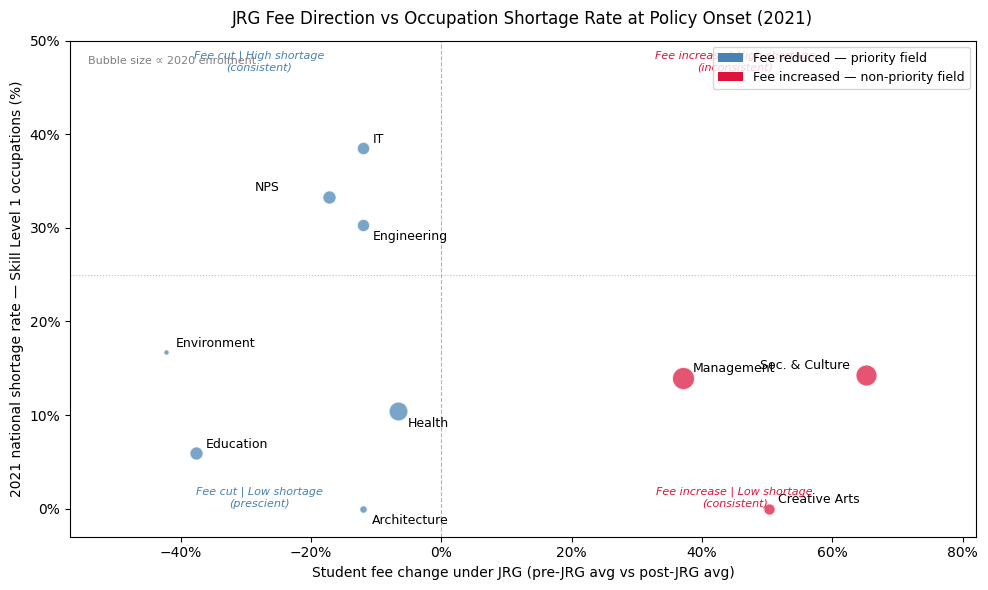

In [3]:
# Scatter: fee change (x) vs 2021 shortage rate (y); bubble size = 2020 enrolment
OFFSETS = {
    'IT':             (7,   4), 'NPS':          (-54,  4),
    'Engineering':    (7, -11), 'Architecture': (  7, -11),
    'Environment':    (7,   4), 'Health':       (  7, -11),
    'Education':      (7,   4), 'Management':   (  7,   4),
    'Soc. & Culture': (-76, 4), 'Creative Arts': ( 7,   4),
}

fig, ax = plt.subplots(figsize=(10, 6))

for key in range(1, 11):
    row   = summary.loc[key]
    x     = row['FeeChange']
    y     = row['Shortage 2021 (%)']
    size  = row['Enrolment 2020'] / 1500
    color = 'steelblue' if x < 0 else 'crimson'
    label = SHORT_LABELS.get(row['Category'], row['Category'])
    ax.scatter(x, y, s=size, color=color, alpha=0.72, edgecolors='white', linewidth=0.8, zorder=3)
    ox, oy = OFFSETS.get(label, (7, 4))
    ax.annotate(label, (x, y), textcoords='offset points', xytext=(ox, oy), fontsize=9)

ax.axvline(0,  color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(25, color='gray', linestyle=':',  linewidth=0.8, alpha=0.5)
ax.set_xlim(-57, 82)
ax.set_ylim(-3,  50)
ax.set_xlabel('Student fee change under JRG (pre-JRG avg vs post-JRG avg)', fontsize=10)
ax.set_ylabel('2021 national shortage rate — Skill Level 1 occupations (%)', fontsize=10)
ax.set_title('JRG Fee Direction vs Occupation Shortage Rate at Policy Onset (2021)', fontsize=12, pad=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.text(-28,  49, 'Fee cut | High shortage\n(consistent)', fontsize=8,
        color='steelblue', ha='center', va='top', style='italic')
ax.text( 45,  49, 'Fee increase | High shortage\n(inconsistent)', fontsize=8,
        color='crimson',   ha='center', va='top', style='italic')
ax.text(-28,   0, 'Fee cut | Low shortage\n(prescient)', fontsize=8,
        color='steelblue', ha='center', va='bottom', style='italic')
ax.text( 45,   0, 'Fee increase | Low shortage\n(consistent)', fontsize=8,
        color='crimson',   ha='center', va='bottom', style='italic')

ax.text(0.02, 0.97, 'Bubble size ∝ 2020 enrolment', transform=ax.transAxes,
        fontsize=8, color='gray', va='top')

legend_elements = [
    Patch(facecolor='steelblue', label='Fee reduced — priority field'),
    Patch(facecolor='crimson',   label='Fee increased — non-priority field'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

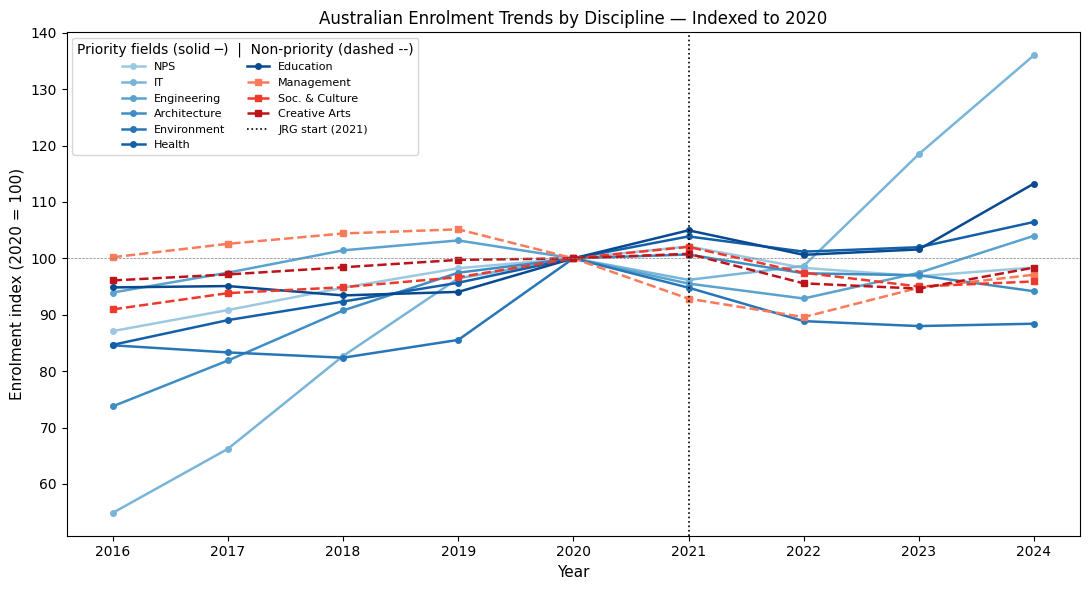

In [4]:
# Enrolment indexed to 2020 = 100 for all 10 categories
years_int = list(range(2016, 2025))
years_str = [str(y) for y in years_int]
base_year = '2020'

PRIORITY_KEYS     = [1, 2, 3, 4, 5, 6, 7]   # fee cut
NON_PRIORITY_KEYS = [8, 9, 10]               # fee increase

p_colors  = plt.cm.Blues(np.linspace(0.38, 0.90, len(PRIORITY_KEYS)))
np_colors = plt.cm.Reds( np.linspace(0.45, 0.80, len(NON_PRIORITY_KEYS)))

fig, ax = plt.subplots(figsize=(11, 6))

for i, key in enumerate(PRIORITY_KEYS):
    row  = enroll.loc[key]
    vals = row[years_str].values.astype(float)
    base = row[base_year]
    idx  = vals / base * 100
    label = SHORT_LABELS.get(row['Category'], row['Category'])
    ax.plot(years_int, idx, 'o-', color=p_colors[i], linewidth=1.8, markersize=4, label=label)

for i, key in enumerate(NON_PRIORITY_KEYS):
    row  = enroll.loc[key]
    vals = row[years_str].values.astype(float)
    base = row[base_year]
    idx  = vals / base * 100
    label = SHORT_LABELS.get(row['Category'], row['Category'])
    ax.plot(years_int, idx, 's--', color=np_colors[i], linewidth=1.8, markersize=4, label=label)

ax.axvline(2021, color='black', linestyle=':', linewidth=1.2, label='JRG start (2021)')
ax.axhline(100,  color='gray',  linestyle='--', linewidth=0.5)
ax.set_xticks(years_int)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Enrolment index (2020 = 100)', fontsize=11)
ax.set_title('Australian Enrolment Trends by Discipline — Indexed to 2020', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='upper left',
          title='Priority fields (solid ─)  |  Non-priority (dashed --)')
plt.tight_layout()
plt.show()

## Key Findings

### 1. Were fee cuts targeted at shortage fields?

Partially, and in some cases prescientlly. The three fields with the highest shortage rates in 2021 — IT (39%), NPS (33%), and Engineering (30%) — all received fee cuts under JRG. Creative Arts, with essentially no shortage throughout the period, received a large fee increase (+50%). These are broadly consistent decisions.

However, three fee-cut fields had low shortage rates at JRG onset. **Education** (6% shortage in 2021, −38% fee change) and **Architecture** (0% shortage, −12%) appear inconsistent with current labour-market signals at the time, yet both saw shortages surge dramatically afterward — Education reached 47% by 2022 and has remained there; Architecture reached 100% by 2025. **Health** had only a 10% shortage in 2021 despite receiving a fee cut, but its shortage exploded to 80% by 2023 and remained at 74% in 2025. In each of these cases, the government appears to have anticipated emerging shortages rather than responding only to current data.

On the non-priority side, **Management & Commerce** (+37% fee increase) and **Society & Culture** (+65% fee increase) both had moderate shortage rates of ~14% in 2021 — not zero, but well below the fields identified as priority. Both saw their shortages decline by 2025 (to 4% and 24% respectively), consistent with the fee increases reducing entry into these fields. No field with a fee increase ended up in the top-right quadrant of high shortage and rising fees — the most problematic combination.

### 2. Did high-shortage fields have high or low enrolments?

High-shortage fields were not uniformly under-enrolled before JRG. **Health** was the second-largest field by enrolment in 2020 (278k), yet developed the most acute shortage by 2023. This reflects a fundamental demand-supply imbalance — the shortage in health occupations is structural, driven by retirement, population ageing, and expanding health service needs, not by an absence of students. **IT** (121k) and **Engineering** (118k) had medium enrolments and high shortages — consistent with demand outpacing graduate supply in those sectors.

The two largest enrolled fields — **Management & Commerce** (380k) and **Society & Culture** (344k) — had the lowest shortage rates. These fields were over-supplied relative to labour-market demand, which is precisely why the JRG increased their fees. The scatter chart makes this relationship visible: bubble size (enrolment) tends to be largest on the right side (non-priority, fee increases) and smallest in the upper-left (high shortage, fee cut).

### 3. How have enrolments responded post-JRG?

**IT** shows the clearest supply response: enrolment grew 36% from 2020 to 2024, and the shortage rate fell from 39% to 21%. This reflects a combination of the fee incentive and independent labour-market demand from the tech sector reinforcing each other.

**Education** grew 13% from 2020 to 2024. The shortage remains at 47%, suggesting the fee cut has increased supply but that demand for teachers continues to outpace it.

**Health** grew 6.5% despite having the most acute shortage in the dataset (74% in 2025). The fee cut was the smallest of the priority fields (−7%), and the structural depth of the health workforce gap appears to be beyond what fee incentives alone can address.

Notably, three fee-cut fields — **NPS** (−1.6%), **Architecture** (−5.8%), and **Environment** (−11.6%) — all saw enrolment decline from 2020 to 2024 despite receiving fee reductions. In these fields, fee incentives appear insufficient to override other drivers such as weak domestic job-market signals and limited student awareness of shortage conditions. Environment's decline is particularly striking given it received the largest fee cut (−42%) of any field.

**Non-priority fields declined modestly** after fee increases: M&C −2.9%, Society & Culture −4.1%, Creative Arts −1.6%. These are relatively small changes, suggesting students respond to fee signals but with meaningful inertia — field choice is not purely price-sensitive.

### Overall pattern

The JRG fee changes were broadly consistent with pre-existing shortage data for the highest-demand fields (IT, Engineering, NPS) and clearly appropriate for the lowest-shortage fields (Creative Arts, M&C). The policy also appears to have been forward-looking for Education, Architecture, and Health, where shortages emerged or intensified sharply after 2021. Enrolment responses were mixed: the largest response occurred where fee cuts and labour market demand reinforced each other (IT), while fee cuts alone proved insufficient where career signals were weaker (Architecture, Environment, NPS).